In [1]:
import networkx as nx
import requests
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import re
import os
import urllib

# This notebook convert voting_id's to a dataframe of votes

In [ ]:
base_url = "https://oda.ft.dk/api/"
    
n_votes = 500
def get_voting_sessions_in_period():
    # Get all voting ID´s in a specific period to pass to "get_voting_session_with_votes"
    # voting_ids= [10375, 10376, 10377, 10378] #
    voting_ids = range(10379-n_votes, 10379)
    return voting_ids

def get_voting_session_with_votes(voting_id):
    base_url = "https://oda.ft.dk/api/"
    """Retrieve a complete voting session with all individual votes"""
    params = {
        '$expand': 'Stemme/Aktør',
        '$filter': f'id eq {voting_id}'
    }
    url = f"{base_url}Afstemning"
    response = requests.get(url, params=params)
    if response.status_code != 200: #If the response is not ok print it and continue, no need to break the program.
        print(f"HTTP error for {voting_id}: ", response.status_code)
        print("Response text:", response.text)
    else:
        try:
            data = response.json()
        except ValueError:
            print("Error: Response is not valid JSON")
            print("Response text:", response.text)
        return data

def get_data_from_voting_session(voting_id, data_from_voting_session):
    if data_from_voting_session['value']:

        vote_data = []

        # for aktør 
        data = data_from_voting_session['value'][0].get('Stemme')
        
        for individual_vote in data:
            # return_data = individual_vote
            # return_data = individual_vote.get('Aktør').get('biografi') #This is useful for finding the information about the person who voted.

            politician_bio = individual_vote.get('Aktør').get('biografi')
            politician_party = re.search('<party>([^<]+)</party>', politician_bio).group(1) #Extract the party
            politician_name = individual_vote.get('Aktør').get('navn') #Find the name of who votes. We will use this for naming the nodes.
            vote_type = individual_vote.get('typeid') #What did they vote?
            # vote_data.append((politician_name, voting_id, {'vote_type':vote_type})) #Need to pass the last part as dictionary for networkx to understand it

            # POTENTIALLY SKIP IF THEY WERE ABSENT FOR THE VOTE
            if vote_type == 3:
                continue
            vote_data.append((voting_id, politician_party, politician_name, vote_type)) #Will pass to DF instead, so no need for dict 
            # print(vote_data)
    
    # return vote_data
    df = pd.DataFrame(vote_data, columns = ['voting_id', 'party', 'politician', 'vote_type'])
    return df
    # return return_data #This is if we want to see example output to understand the structure.

# voting_id = 10377
# data = get_voting_session_with_votes(voting_id)
# df = get_data_from_voting_session(voting_id=voting_id, data_from_voting_session=data)
# df
# # df.head()

voting_sessions = get_voting_sessions_in_period()
df = pd.DataFrame()
for voting_id in voting_sessions:
    data = get_voting_session_with_votes(voting_id)
    df_addition = get_data_from_voting_session(voting_id=voting_id, data_from_voting_session=data)    
    df = pd.concat([df, df_addition])

In [ ]:
df.to_csv("./final-project/graphs/df_votes", index = False)

In [6]:
with urllib.request.urlopen("https://raw.githubusercontent.com/Somon8/social_graphs_25/main/final-project/graphs/df_voting_sessions.csv") as response:
    df = pd.read_csv(response)

HTTPError: HTTP Error 404: Not Found

In [65]:
# For each unique politician create a DF
# For each other unique politician
# Count how many voting id´s they share
# Count how many voting id's they have the same value in
# Cakculate agreement percentage
# Add it as edges to a graph
G = nx.Graph()
#Let's do some agreement stuff
# def create_network_from_theme(df):
#     return G

#WE could also already have filtered the dataframe here by theme or something like that. It's probably the smartest thing to do.
politician_list = df['politician'].unique()
for idx, politician in enumerate(politician_list):

    df_pol = df[df['politician'] == politician][['voting_id', 'vote_type']]

    for other_politician in politician_list[idx+1:]: #Look at remaining politicians to avoid double work
        df_other = df[df['politician'] == other_politician][['voting_id', 'vote_type']]
        
        #WE NEED TO ADD SOMETHING ABOUT THE THEME HERE?
        total_df = df_pol.merge(df_other, on='voting_id', how='inner') #Count how many voting_id's they share
        agree_df = df_pol.merge(df_other, on=['voting_id', 'vote_type'], how='inner') #Count share where they also voted the same
        total = len(total_df)
        agree = len(agree_df)

        agree_percent = agree / total if total > 0 else 0
        G.add_edge(politician, other_politician, weight=agree_percent)

In [ ]:
df.to_csv("graphs/node_df.csv", index = True)

In [69]:
# DOES THIS EVEN MAKE SENSE?
g_df = nx.to_pandas_edgelist(G)

# g_df['weight']
g_df[g_df['target'] == "Aki-Matilda Høegh-Dam"]
# df_draw[df_draw['target'] == "Aki-Matilda Høegh-Dam"]
# g_df[g_df['weight'] > agreement_threshold]

,source,target,weight
104,Alex Ahrendtsen,Aki-Matilda Høegh-Dam,0.333333
216,Søren Espersen,Aki-Matilda Høegh-Dam,0.000000
327,Erling Bonnesen,Aki-Matilda Høegh-Dam,0.000000
437,Mette Reissmann,Aki-Matilda Høegh-Dam,0.000000
546,Torsten Schack Pedersen,Aki-Matilda Høegh-Dam,0.666667
...,...,...,...
6354,Eva Kjer Hansen,Aki-Matilda Høegh-Dam,0.000000
6366,Halime Oguz,Aki-Matilda Høegh-Dam,0.000000
6377,Lars Løkke Rasmussen,Aki-Matilda Høegh-Dam,0.000000
6387,Mona Juul,Aki-Matilda Høegh-Dam,1.000000


6441 2315


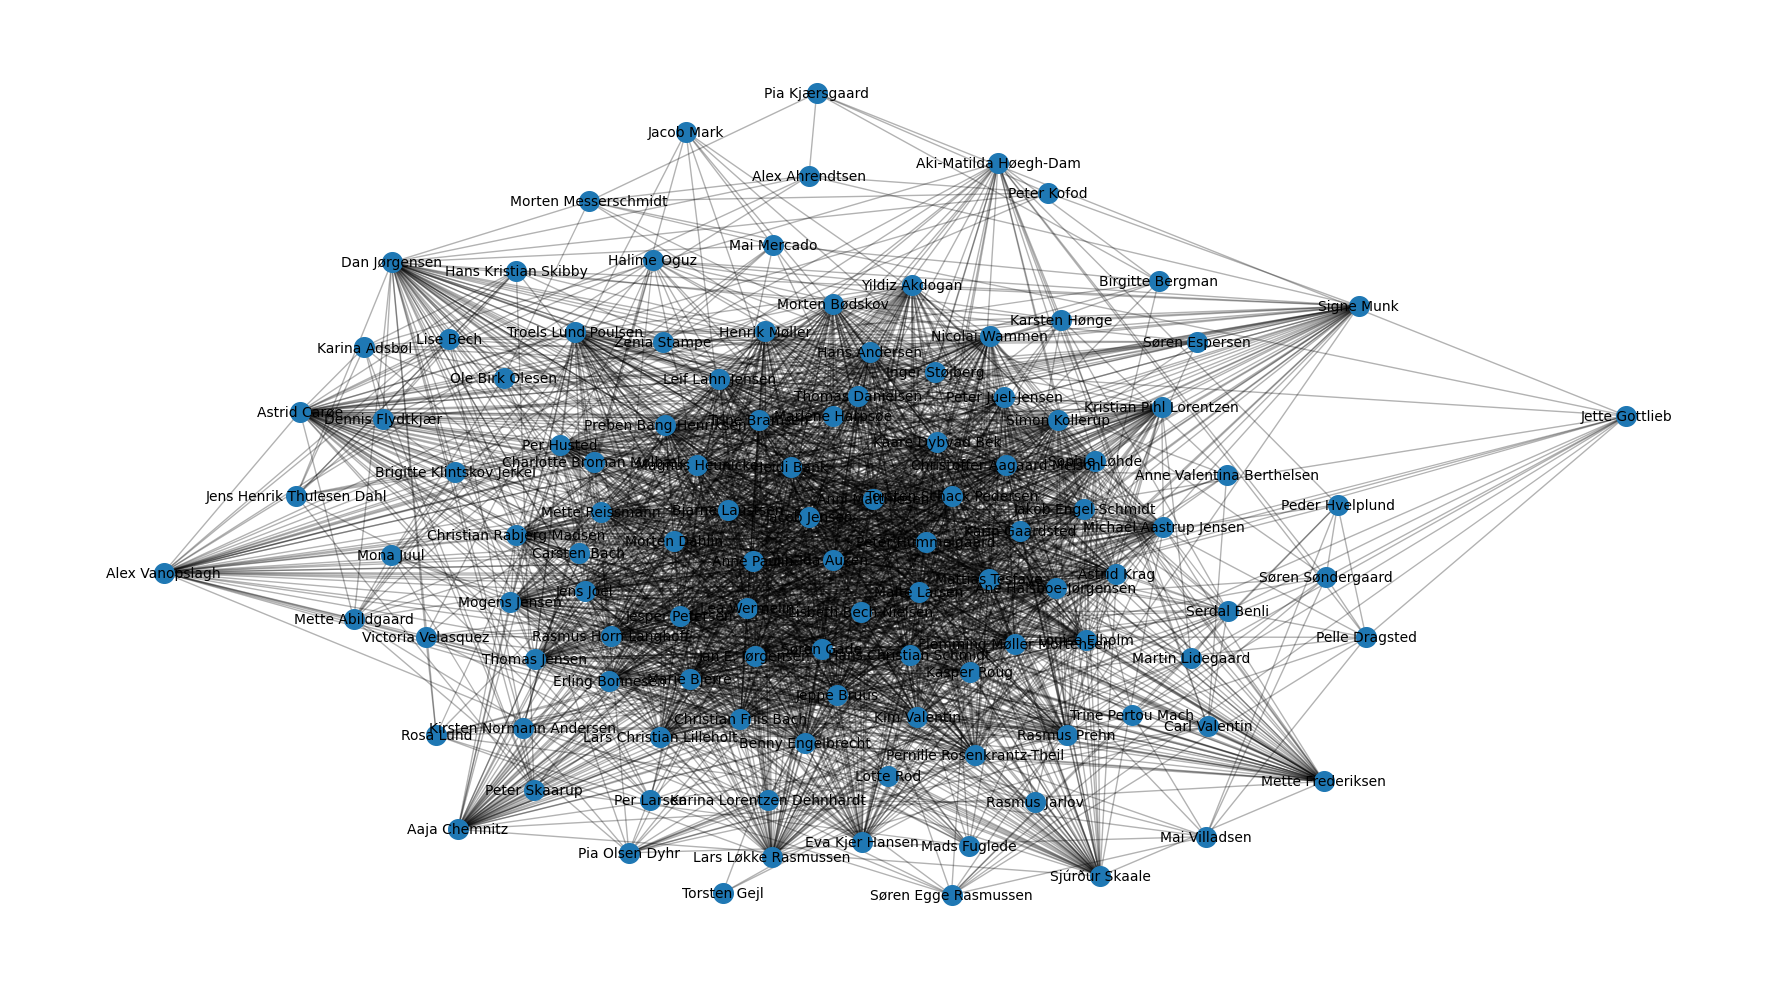

In [68]:
figure, axs = plt.subplots(1,1,figsize = (18,10)) #Width, Height

pos = nx.forceatlas2_layout(G
                                        , seed = 42
                                        , weight = "weight"
                                        )

# nodes
agreement_threshold = 0.9
df_draw = g_df[g_df['weight'] > agreement_threshold]

print(len(g_df), len(df_draw))

#Get the edges and widths to draw
edges = list(zip(df_draw['source'], df_draw['target']))
edge_widths = df_draw['weight'].tolist()


nx.draw_networkx_nodes(G, pos, node_size=200, ax = axs)

# edges
nx.draw_networkx_edges(G, pos, edgelist=edges, width=[w * 1 for w in edge_widths], alpha = 0.3, ax = axs)


# node labels
nx.draw_networkx_labels(G, pos, font_size=10, ax = axs)


# ax.margins(0.08)
plt.axis("off")
plt.tight_layout()
plt.show()